In [51]:
import numpy as np
from astropy.table import Table, join
from astropy import units as u
from astropy.coordinates import SkyCoord

import matplotlib.pyplot as plt

# Color definitions for consistent plotting
color_quaia_var = 'cornflowerblue'
color_quaia_nonvar = 'grey'
color_var_notquaia = '#C0392B'  # nice muted red
# Colors for big overplotted points (errorbars)
color_bins_quaia_var = 'navy'
color_bins_quaia_nonvar = 'black'
color_bins_var_notquaia = 'crimson'

In [41]:
# Load catalogs
tab_var = Table.read('../data/gaia_vari_agn.fits')
tab_quaia = Table.read('../data/quaia_G20.5.fits')
print('gaia_vari_agn:', len(tab_var), '| quaia_G20.5:', len(tab_quaia))

gaia_vari_agn: 872228 | quaia_G20.5: 1295502


In [42]:
# Load DR16Q property catalog and crossmatch to tab_quaia (sky position)
tab_dr16q = Table.read('../data/dr16q_prop_May01_2024.fits.gz')
print('dr16q_prop:', len(tab_dr16q))

dr16q_prop: 750414


In [43]:
tab_dr16q.columns

<TableColumns names=('SDSS_NAME','PLATE','MJD','FIBERID','RA','DEC','OBJID','IF_BOSS_SDSS','Z_DR16Q','SOURCE_Z_DR16Q','Z_FIT','Z_SYS','Z_SYS_ERR','EBV','SN_MEDIAN_ALL','CONTI_FIT','CONTI_FIT_ERR','CONTI_STAT','FEII_UV','FEII_UV_ERR','FEII_UV_EW','FEII_UV_EW_ERR','FEII_OPT','FEII_OPT_ERR','FEII_OPT_EW','FEII_OPT_EW_ERR','LOGL1350','LOGL1350_ERR','LOGL1700','LOGL1700_ERR','LOGL2500','LOGL2500_ERR','LOGL3000','LOGL3000_ERR','LOGL5100','LOGL5100_ERR','HALPHA','HALPHA_BR','NII6585','SII6718','HBETA','HBETA_BR','HEII4687','HEII4687_BR','OIII5007','OIII5007C','CAII3934','OII3728','NEV3426','MGII','MGII_BR','CIII_ALL','CIII_BR','SIIII1892','ALIII1857','NIII1750','CIV','HEII1640','HEII1640_BR','SIIV_OIV','OI1304','LYA','NV1240','HALPHA_ERR','HALPHA_BR_ERR','NII6585_ERR','SII6718_ERR','HBETA_ERR','HBETA_BR_ERR','HEII4687_ERR','HEII4687_BR_ERR','OIII5007_ERR','OIII5007C_ERR','CAII3934_ERR','OII3728_ERR','NEV3426_ERR','MGII_ERR','MGII_BR_ERR','CIII_ALL_ERR','CIII_BR_ERR','SIIII1892_ERR','ALIII1857

In [44]:
# Join on source_id: add only var columns not in quaia (no duplicate col names / _1 suffixes)
cols_quaia = set(tab_quaia.colnames)
cols_var_only = [c for c in tab_var.colnames if c not in cols_quaia]
tab_var_extra = tab_var[['source_id'] + cols_var_only]
tab_quaia = join(tab_quaia, tab_var_extra, keys='source_id', join_type='left')

# Sources in both = quaia rows that have a var match
mask_quaia_only = ~np.isin(tab_quaia['source_id'], tab_var['source_id'])
tab_both = tab_quaia[~mask_quaia_only]
tab_quaia_only = tab_quaia[mask_quaia_only]
print('In both:', len(tab_both))
print('Only in quaia:', len(tab_quaia_only))

# Only in vari_agn
mask_var_only = ~np.isin(tab_var['source_id'], tab_quaia['source_id'])
tab_var_only = tab_var[mask_var_only]
print('Only in vari_agn:', len(tab_var_only))

# Checks: both + only = original
assert len(tab_both) + len(tab_var_only) == len(tab_var), 'vari_agn: both + only != total'
assert len(tab_both) + len(tab_quaia_only) == len(tab_quaia), 'quaia: both + only != total'
print('Checks OK.')

In both: 713816
Only in quaia: 581686
Only in vari_agn: 158412
Checks OK.


In [45]:

# DR16Q uses RA, DEC (or PLUG_RA, PLUG_DEC); QUaIA uses ra, dec
# Convert to plain degree arrays (FITS may give Quantity or masked columns)
def _to_deg(col):
    data = col.data if hasattr(col, 'mask') else col
    a = np.asarray(data)
    if hasattr(a, 'to'):
        a = a.to(u.deg).value
    elif hasattr(a, 'value'):
        a = np.asarray(a.value)
    a = np.asarray(a, dtype=float)
    if hasattr(col, 'mask') and np.any(col.mask):
        a = np.where(col.mask, np.nan, a)
    return a

ra_dr16 = _to_deg(tab_dr16q['RA'] if 'RA' in tab_dr16q.colnames else tab_dr16q['PLUG_RA'])
dec_dr16 = _to_deg(tab_dr16q['DEC'] if 'DEC' in tab_dr16q.colnames else tab_dr16q['PLUG_DEC'])
ra_quaia = _to_deg(tab_quaia['ra'])
dec_quaia = _to_deg(tab_quaia['dec'])

coords_dr16q = SkyCoord(ra=ra_dr16 * u.deg, dec=dec_dr16 * u.deg, frame='icrs')
coords_quaia = SkyCoord(ra=ra_quaia * u.deg, dec=dec_quaia * u.deg, frame='icrs')

idx_quaia, sep2d, _ = coords_dr16q.match_to_catalog_sky(coords_quaia)
# Keep only nearest match within 1 arcsec; otherwise idx_quaia = -1 (no match)
sep_arcsec = sep2d.to(u.arcsec).value
within_1 = sep2d < 1 * u.arcsec
tab_dr16q['idx_quaia'] = np.where(within_1, idx_quaia, -1)
tab_dr16q['sep_arcsec'] = sep_arcsec

# Summary
print('DR16Q × QUaIA: nearest match within 1 arcsec')
print('Valid matches (sep < 1 arcsec):', np.sum(within_1))
print('No match within 1 arcsec:', np.sum(~within_1))

DR16Q × QUaIA: nearest match within 1 arcsec
Valid matches (sep < 1 arcsec): 294591
No match within 1 arcsec: 455823


In [46]:
# LOGMBH per quaia row (from DR16Q match within 1 arcsec)
logmbh_quaia = np.full(len(tab_quaia), np.nan)
for j in range(len(tab_dr16q)):
    i = tab_dr16q['idx_quaia'][j]
    if i >= 0:
        logmbh_quaia[i] = tab_dr16q['LOGMBH'][j]

# Quaia rows with / without variability info (var columns present from left join)
mask_has_var = np.isin(tab_quaia['source_id'], tab_var['source_id'])

In [74]:
# Read has_xp table output by get_spectra.py (same QUaIA base path → ../data/has_xp_quaia_G20.5.fits)
tab_has_xp = Table.read('../data/has_xp_quaia_G20.5.fits')
for old, new in [("SOURCE_ID", "source_id"), ("HAS_XP_CONTINUOUS", "has_xp_continuous"), ("HAS_XP_SAMPLED", "has_xp_sampled")]:
    if old in tab_has_xp.colnames and old != new:
        tab_has_xp.rename_column(old, new)

In [75]:
print(len(tab_has_xp[tab_has_xp['has_xp_continuous']]))
print(len(tab_has_xp[tab_has_xp['has_xp_sampled']]))

115104
24


In [64]:
# Sources with XP spectra (gaiaxpy_calibrated uses has_xp_continuous)
mask_has_xp = np.asarray(tab_has_xp['has_xp_continuous']).astype(bool)
source_ids_with_xp = np.array(tab_has_xp['source_id'][mask_has_xp])
# Quaia source_ids that are in SDSS (from DR16Q crossmatch above: idx_quaia >= 0)
idx_valid = tab_dr16q['idx_quaia'][tab_dr16q['idx_quaia'] >= 0]
quaia_source_ids_in_sdss = np.unique(tab_quaia['source_id'][idx_valid])
# How many of the has_xp_spectra sources are in SDSS?
n_xp_total = len(source_ids_with_xp)
n_xp_in_sdss = np.sum(np.isin(source_ids_with_xp, quaia_source_ids_in_sdss))
print(f'QUaIA sources with XP spectra (has_xp_continuous): {n_xp_total}')
print(f'Of those, in SDSS (DR16Q crossmatch <1 arcsec): {n_xp_in_sdss} ({100*n_xp_in_sdss/n_xp_total:.1f}%)')

QUaIA sources with XP spectra (has_xp_continuous): 115104
Of those, in SDSS (DR16Q crossmatch <1 arcsec): 35944 (31.2%)


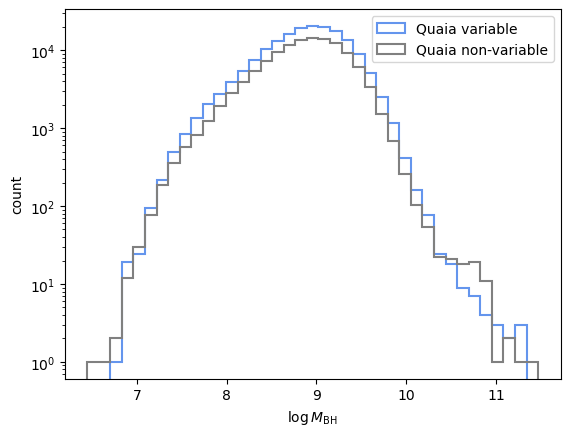

With var (and LOGMBH): 172895 | No var (and LOGMBH): 121131


In [65]:

valid_bhm = np.isfinite(logmbh_quaia) & (logmbh_quaia > 0)
logmbh_with_var = logmbh_quaia[mask_has_var & valid_bhm]
logmbh_no_var = logmbh_quaia[~mask_has_var & valid_bhm]

# Histogram of log M_BH
bins = np.linspace(min(logmbh_quaia[valid_bhm]), max(logmbh_quaia[valid_bhm]), 40)
plt.hist(logmbh_with_var, bins=bins, histtype='step', label='Quaia variable', color=color_quaia_var, linewidth=1.5)
plt.hist(logmbh_no_var, bins=bins, histtype='step', label='Quaia non-variable', color=color_quaia_nonvar, linewidth=1.5)
plt.xlabel(r'$\log M_{\rm BH}$')
plt.ylabel('count')
plt.legend()
plt.yscale('log')
plt.show()
print('With var (and LOGMBH):', len(logmbh_with_var), '| No var (and LOGMBH):', len(logmbh_no_var))

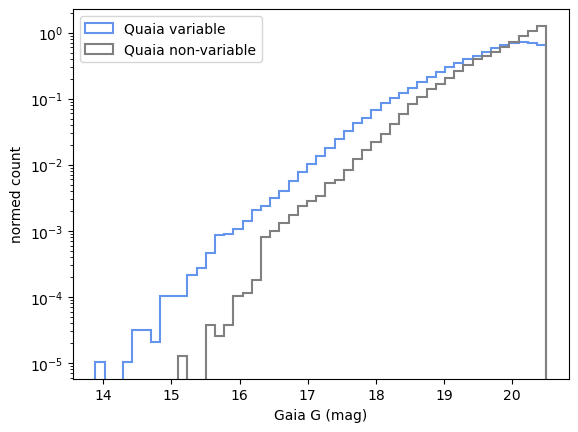

With var: 713816 | No var: 581686


In [66]:
# Gaia G brightness (col_G) for quaia with vs without var (no SDSS)
col_G = 'phot_g_mean_mag'
g_with_var = np.asarray(tab_quaia[col_G][mask_has_var])
g_no_var = np.asarray(tab_quaia[col_G][~mask_has_var])
# Strip units if present
if hasattr(g_with_var, 'value'):
    g_with_var = g_with_var.value
if hasattr(g_no_var, 'value'):
    g_no_var = g_no_var.value
g_with_var = np.asarray(g_with_var, dtype=float)
g_no_var = np.asarray(g_no_var, dtype=float)
g_all = np.concatenate([g_with_var, g_no_var])
g_valid = np.isfinite(g_all)
bins_G = np.linspace(np.nanmin(g_all[g_valid]) if np.any(g_valid) else 0,
                     np.nanmax(g_all[g_valid]) if np.any(g_valid) else 25, 50)

plt.hist(g_with_var[np.isfinite(g_with_var)], bins=bins_G, histtype='step', label='Quaia variable', density=True, color=color_quaia_var, linewidth=1.5)
plt.hist(g_no_var[np.isfinite(g_no_var)], bins=bins_G, histtype='step', label='Quaia non-variable', density=True, color=color_quaia_nonvar, linewidth=1.5)
plt.xlabel('Gaia G (mag)')
plt.ylabel('normed count')
plt.legend()
plt.yscale('log')
plt.show()
print('With var:', np.sum(np.isfinite(g_with_var)), '| No var:', np.sum(np.isfinite(g_no_var)))

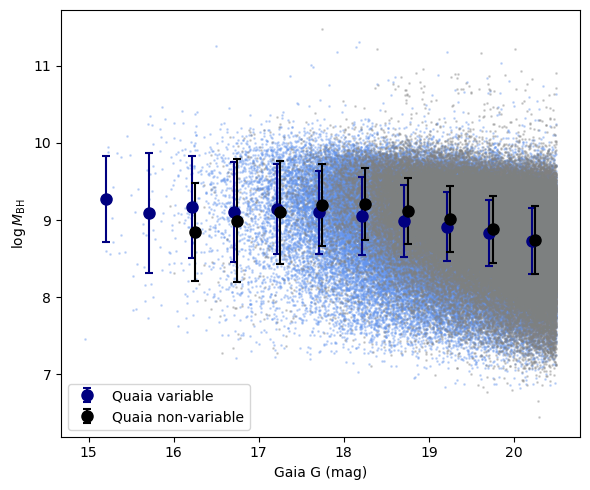

Quaia with var: 172895 | Quaia non-var: 121131 | Var not in quaia: 0


In [67]:
# Scatter: log M_BH vs col_G — Quaia with var, Quaia non-var, Var not in quaia
col_G = 'phot_g_mean_mag'
g_quaia = np.asarray(tab_quaia[col_G], dtype=float)
if hasattr(g_quaia, 'value'):
    g_quaia = np.asarray(g_quaia.value, dtype=float)
ok_var = mask_has_var & np.isfinite(g_quaia) & np.isfinite(logmbh_quaia) & (logmbh_quaia > 0)
ok_novar = ~mask_has_var & np.isfinite(g_quaia) & np.isfinite(logmbh_quaia) & (logmbh_quaia > 0)

# Crossmatch tab_var_only with DR16Q to get LOGMBH
# tab_var_only is subset of tab_var, so look up coordinates and G from tab_var via source_id
# Use join for efficiency
tab_var_lookup = tab_var[['source_id'] + ([c for c in ['ra', 'dec', col_G] if c in tab_var.colnames])]
tab_var_only_with_coords = join(tab_var_only, tab_var_lookup, keys='source_id', join_type='left')

# Get coordinates
if 'ra' in tab_var_only_with_coords.colnames and 'dec' in tab_var_only_with_coords.colnames:
    ra_var_only = _to_deg(tab_var_only_with_coords['ra'])
    dec_var_only = _to_deg(tab_var_only_with_coords['dec'])
else:
    ra_var_only = np.full(len(tab_var_only), np.nan)
    dec_var_only = np.full(len(tab_var_only), np.nan)
    print('Warning: Cannot find ra/dec for var_notquaia. Skipping crossmatch.')

# Get Gaia G magnitudes
if col_G in tab_var_only_with_coords.colnames:
    g_var_only = np.asarray(tab_var_only_with_coords[col_G], dtype=float)
    if hasattr(g_var_only, 'value'):
        g_var_only = np.asarray(g_var_only.value, dtype=float)
else:
    g_var_only = np.full(len(tab_var_only), np.nan)

# Crossmatch with DR16Q if we have coordinates
valid_coords = np.isfinite(ra_var_only) & np.isfinite(dec_var_only)
if np.sum(valid_coords) > 0:
    coords_var_only = SkyCoord(ra=ra_var_only[valid_coords] * u.deg, dec=dec_var_only[valid_coords] * u.deg, frame='icrs')
    idx_dr16_var_only, sep2d_var_only, _ = coords_var_only.match_to_catalog_sky(coords_dr16q)
    within_1_var_only = sep2d_var_only < 1 * u.arcsec
    
    # LOGMBH for var_notquaia
    logmbh_var_only = np.full(len(tab_var_only), np.nan)
    valid_indices = np.where(valid_coords)[0]
    for j, idx in enumerate(valid_indices):
        i_dr16 = idx_dr16_var_only[j]
        if within_1_var_only[j] and i_dr16 >= 0:
            logmbh_var_only[idx] = tab_dr16q['LOGMBH'][i_dr16]
else:
    logmbh_var_only = np.full(len(tab_var_only), np.nan)

ok_var_only = np.isfinite(g_var_only) & np.isfinite(logmbh_var_only) & (logmbh_var_only > 0)

plt.figure(figsize=(6, 5))
plt.scatter(g_quaia[ok_var], logmbh_quaia[ok_var], s=1, alpha=0.3, c=color_quaia_var)
plt.scatter(g_quaia[ok_novar], logmbh_quaia[ok_novar], s=1, alpha=0.3, c=color_quaia_nonvar)
#plt.scatter(g_var_only[ok_var_only], logmbh_var_only[ok_var_only], s=1, alpha=0.3, label='Var not in quaia', c=color_var_notquaia)
# Half-mag G bins: mean and std of log M_BH per bin, overplotted with slight G offset
g_all = np.concatenate([g_quaia[np.isfinite(g_quaia)], g_var_only[np.isfinite(g_var_only)]])
g_edges = np.arange(np.floor(g_all.min()), np.ceil(g_all.max()) + 0.5, 0.5)
offset = 0.04  # mag offset so var and nonvar don't overlap
for (g_vals, logmbh_vals, g_off, color, lab) in [
    (g_quaia[ok_var], logmbh_quaia[ok_var], -offset, color_bins_quaia_var, 'Quaia variable'),
    (g_quaia[ok_novar], logmbh_quaia[ok_novar], 0, color_bins_quaia_nonvar, 'Quaia non-variable'),
    #(g_var_only[ok_var_only], logmbh_var_only[ok_var_only], offset, color_bins_var_notquaia, 'Var not in quaia (bins)'),
]:
    bin_idx = np.digitize(g_vals, g_edges) - 1
    bin_idx = np.clip(bin_idx, 0, len(g_edges) - 2)
    centers, means, stds = [], [], []
    for k in range(len(g_edges) - 1):
        m = bin_idx == k
        if np.sum(m) < 2:
            continue
        centers.append((g_edges[k] + g_edges[k + 1]) / 2 + g_off)
        means.append(np.mean(logmbh_vals[m]))
        stds.append(np.std(logmbh_vals[m]))
    centers, means, stds = np.array(centers), np.array(means), np.array(stds)
    plt.errorbar(centers, means, yerr=stds, fmt='o', ms=8, capsize=3, capthick=1.5, elinewidth=1.5, c=color, label=lab, zorder=5)
plt.xlabel('Gaia G (mag)')
plt.ylabel(r'$\log M_{\rm BH}$')
plt.legend()
plt.tight_layout()
plt.show()
print('Quaia with var:', np.sum(ok_var), '| Quaia non-var:', np.sum(ok_novar), '| Var not in quaia:', np.sum(ok_var_only))

In [68]:
# Load catalogs
tab_var = Table.read('../data/gaia_vari_agn.fits')
tab_quaia = Table.read('../data/quaia_G20.5.fits')
print('gaia_vari_agn:', len(tab_var), '| quaia_G20.5:', len(tab_quaia))

gaia_vari_agn: 872228 | quaia_G20.5: 1295502


In [69]:
# Join on source_id: sources in both catalogs

tab_both = join(tab_var, tab_quaia, keys='source_id')
print('In both:', len(tab_both))

# Only in quaia
mask_quaia_only = ~np.isin(tab_quaia['source_id'], tab_var['source_id'])
tab_quaia_only = tab_quaia[mask_quaia_only]
print('Only in quaia:', len(tab_quaia_only))

# Only in vari_agn
mask_var_only = ~np.isin(tab_var['source_id'], tab_quaia['source_id'])
tab_var_only = tab_var[mask_var_only]
print('Only in vari_agn:', len(tab_var_only))

# Checks: both + only = original
assert len(tab_both) + len(tab_var_only) == len(tab_var), 'vari_agn: both + only != total'
assert len(tab_both) + len(tab_quaia_only) == len(tab_quaia), 'quaia: both + only != total'
print('Checks OK.')

In both: 713816
Only in quaia: 581686
Only in vari_agn: 158412
Checks OK.


In [70]:
tab_var.colnames

['solution_id',
 'source_id',
 'fractional_variability_g',
 'structure_function_index',
 'structure_function_index_scatter',
 'qso_variability',
 'non_qso_variability']

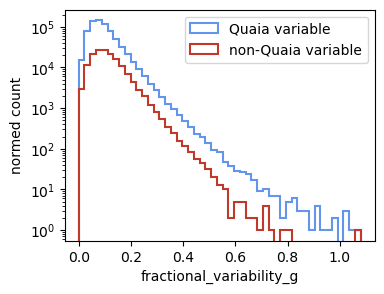

Quaia variable: 713816 | Non-quaia variable: 158412


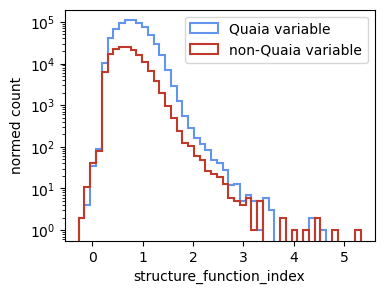

Quaia variable: 713816 | Non-quaia variable: 158412


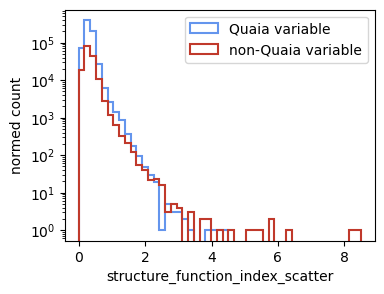

Quaia variable: 713816 | Non-quaia variable: 158412


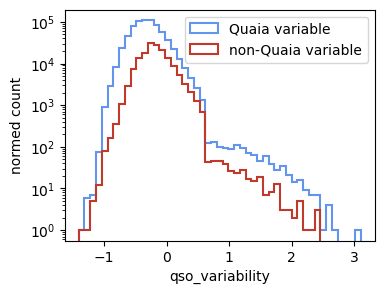

Quaia variable: 713816 | Non-quaia variable: 158412


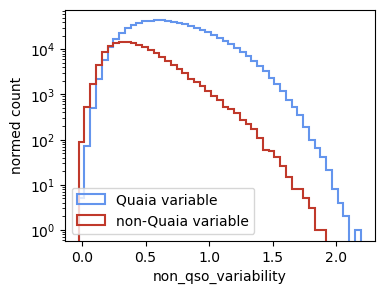

Quaia variable: 713816 | Non-quaia variable: 158412


In [73]:
# Histogram of variability: quaia variable sources vs non-quaia variable sources
#col_var = 'fractional_variability_g'
var_colnames = [c for c in tab_var.colnames if c!='source_id' and c!='solution_id']
for col_var in var_colnames:
    var_quaia_var = np.asarray(tab_both[col_var], dtype=float)
    var_non_quaia = np.asarray(tab_var_only[col_var], dtype=float)
    var_quaia_var = var_quaia_var[np.isfinite(var_quaia_var)]
    var_non_quaia = var_non_quaia[np.isfinite(var_non_quaia)]
    v_all = np.concatenate([var_quaia_var, var_non_quaia])
    bins_var = np.linspace(np.min(v_all), np.max(v_all), 50)

    plt.figure(figsize=(4,3))
    plt.hist(var_quaia_var, bins=bins_var, histtype='step', label='Quaia variable', density=False, color=color_quaia_var, linewidth=1.5)
    plt.hist(var_non_quaia, bins=bins_var, histtype='step', label='non-Quaia variable', density=False, color=color_var_notquaia, linewidth=1.5)
    plt.xlabel(col_var)
    plt.ylabel('normed count')
    plt.legend()
    plt.yscale('log')
    plt.show()
    print('Quaia variable:', len(var_quaia_var), '| Non-quaia variable:', len(var_non_quaia))

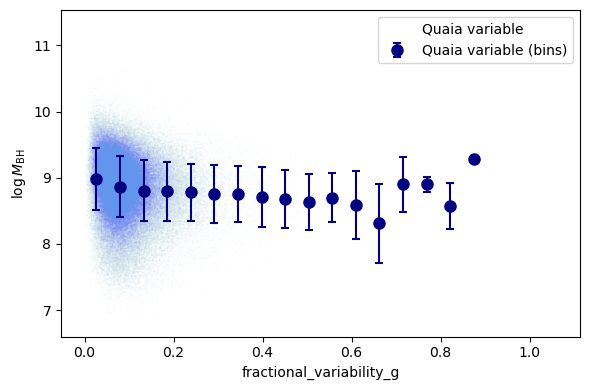

Quaia with var (finite var & LOGMBH): 172895


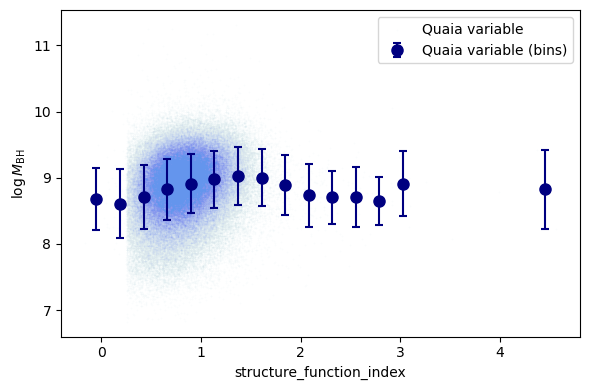

Quaia with var (finite var & LOGMBH): 172895


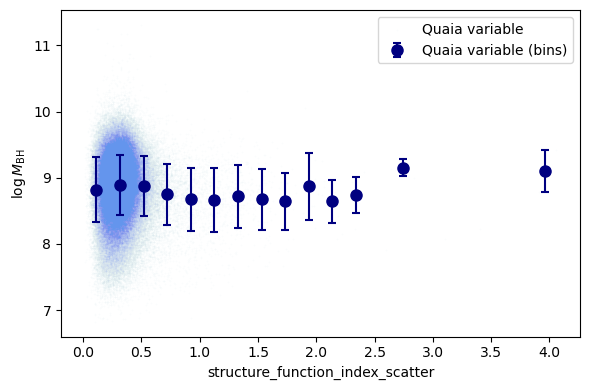

Quaia with var (finite var & LOGMBH): 172895


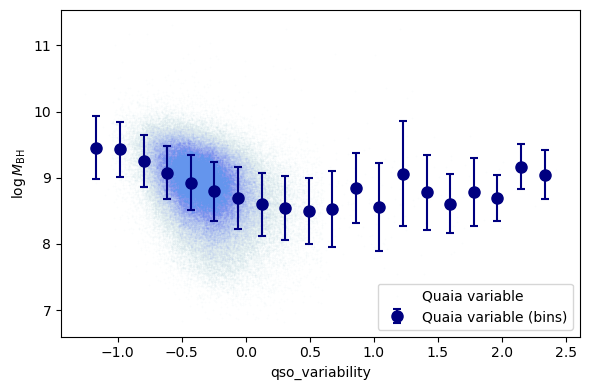

Quaia with var (finite var & LOGMBH): 172895


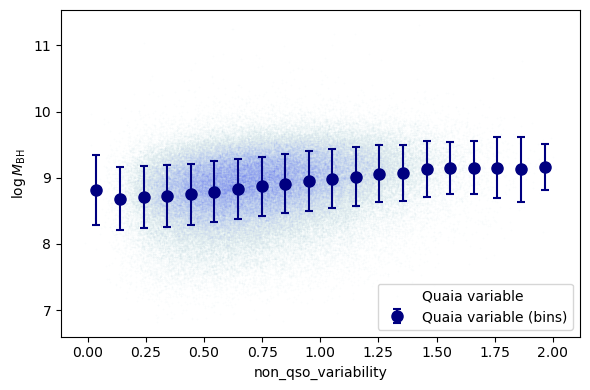

Quaia with var (finite var & LOGMBH): 172895


In [76]:
# Scatter: log M_BH vs fractional variability — Quaia with var (var not in quaia need DR16Q crossmatch for LOGMBH)
for col_var in var_colnames:
    var_both = np.asarray(tab_both[col_var], dtype=float)
    logmbh_both = logmbh_quaia[~mask_quaia_only]  # same row order as tab_both
    ok = np.isfinite(var_both) & np.isfinite(logmbh_both) & (logmbh_both > 0)
    v_vals = var_both[ok]
    logmbh_vals = logmbh_both[ok]
    plt.figure(figsize=(6,4))
    plt.scatter(v_vals, logmbh_vals, s=0.2, alpha=0.02, c=color_quaia_var, label='Quaia variable')
    # Bins: mean and std of log M_BH per variability bin
    n_bins = 20
    v_edges = np.linspace(np.min(v_vals), np.max(v_vals), n_bins + 1)
    bin_idx = np.digitize(v_vals, v_edges) - 1
    bin_idx = np.clip(bin_idx, 0, len(v_edges) - 2)
    centers, means, stds = [], [], []
    for k in range(len(v_edges) - 1):
        m = bin_idx == k
        if np.sum(m) < 2:
            continue
        centers.append((v_edges[k] + v_edges[k + 1]) / 2)
        means.append(np.mean(logmbh_vals[m]))
        stds.append(np.std(logmbh_vals[m]))
    centers, means, stds = np.array(centers), np.array(means), np.array(stds)
    plt.errorbar(centers, means, yerr=stds, fmt='o', ms=8, capsize=3, capthick=1.5, elinewidth=1.5, c=color_bins_quaia_var, label='Quaia variable (bins)', zorder=5)
    # Var not in quaia: would need crossmatch tab_var_only → DR16Q (tab_var has no ra/dec)
    plt.xlabel(col_var)
    plt.ylabel(r'$\log M_{\rm BH}$')
    plt.legend()
    plt.tight_layout()
    plt.show()
    print('Quaia with var (finite var & LOGMBH):', np.sum(ok))